## EDA Notebook

This notebook is set up for exploratory data analysis of the fraud detection dataset.

# Load Data

# Load CSV + import core libraries. Confirms data loaded correctly
# before touching anything else. Column names defined here are used
# in every later step.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../data/raw/creditcard.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Data Quality Check

# Check data types, missing values, and duplicate rows. We clean
# data BEFORE modeling because duplicates and missing values skew
# results. Output tells us what to drop in the preprocessing step.

In [8]:
print("Data types:\n", df.dtypes.value_counts())
print()
print("\nMissing values total:", df.isnull().sum().sum())
print()
print("\nDuplicate rows:", df.duplicated().sum())

Data types:
 float64    30
int64       1
Name: count, dtype: int64


Missing values total: 0


Duplicate rows: 1081


# Class Imbalance

# Count normal vs fraud transactions. This dataset has ~0.172%
# fraud — SEVERE imbalance. This is the #1 challenge. It forces us
# to use AUC-PR, Recall, F1 instead of accuracy, and to apply class
# weights / SMOTE during training.

Class
0    284315
1       492
Name: count, dtype: int64

Fraud %: 0.1727%


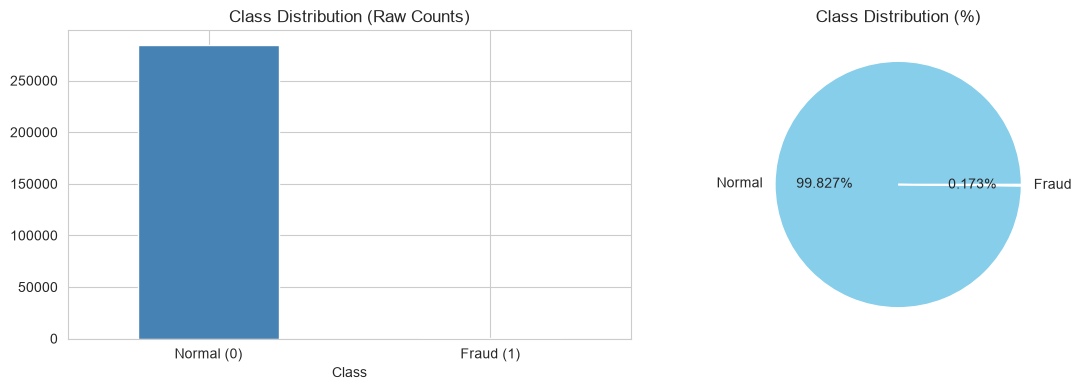

In [18]:
class_counts = df["Class"].value_counts()
print(class_counts)
print(f"\nFraud %: {class_counts[1] / len(df) * 100:.4f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind="bar", ax=ax[0], color=["steelblue", "crimson"])
ax[0].set_title("Class Distribution (Raw Counts)")
ax[0].set_xticklabels(["Normal (0)", "Fraud (1)"], rotation=0)

ax[1].pie(class_counts, labels=["Normal", "Fraud"],
          autopct="%1.3f%%", colors=["skyblue", "crimson"])
ax[1].set_title("Class Distribution (%)")
plt.tight_layout()
plt.show()

# Amount Analysis

# Compare transaction Amount for normal vs fraud. Fraudsters often
# use different amounts than normal users. This confirms whether
# Amount is a useful feature — and tells us to use RobustScaler
# (not StandardScaler) because fraud amounts are outliers.

Amount stats — Normal:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Amount stats — Fraud:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


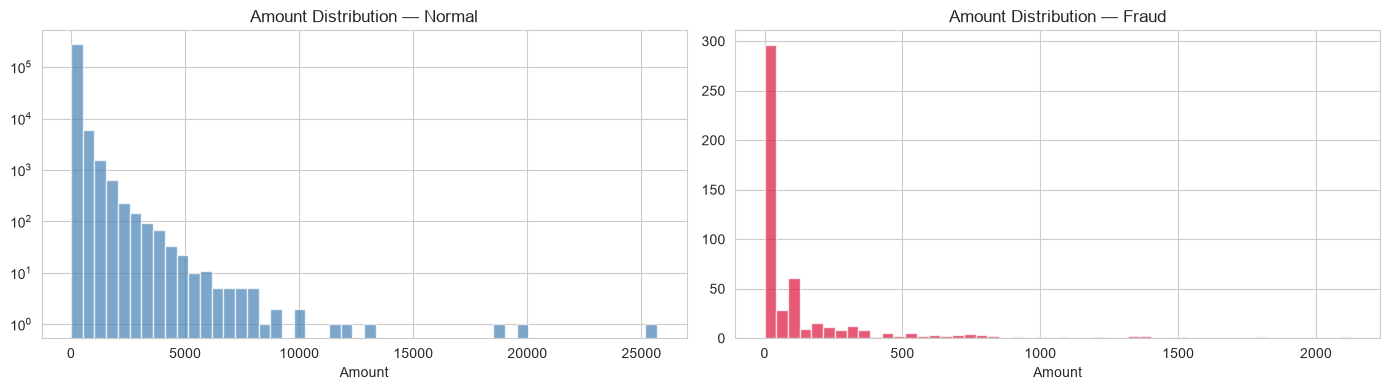

In [19]:
print("Amount stats — Normal:")
print(df[df["Class"] == 0]["Amount"].describe())
print("\nAmount stats — Fraud:")
print(df[df["Class"] == 1]["Amount"].describe())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(df[df["Class"] == 0]["Amount"], bins=50, color="steelblue", alpha=0.7)
ax[0].set_title("Amount Distribution — Normal")
ax[0].set_xlabel("Amount")
ax[0].set_yscale("log")

ax[1].hist(df[df["Class"] == 1]["Amount"], bins=50, color="crimson", alpha=0.7)
ax[1].set_title("Amount Distribution — Fraud")
ax[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

# Time Patterns

# Raw Time column is in seconds since first transaction — useless
# as-is. Convert to Hour-of-day (0-23). Fraud often spikes at night
# when monitoring is low. This feature is engineered into the model
# in the next notebook.

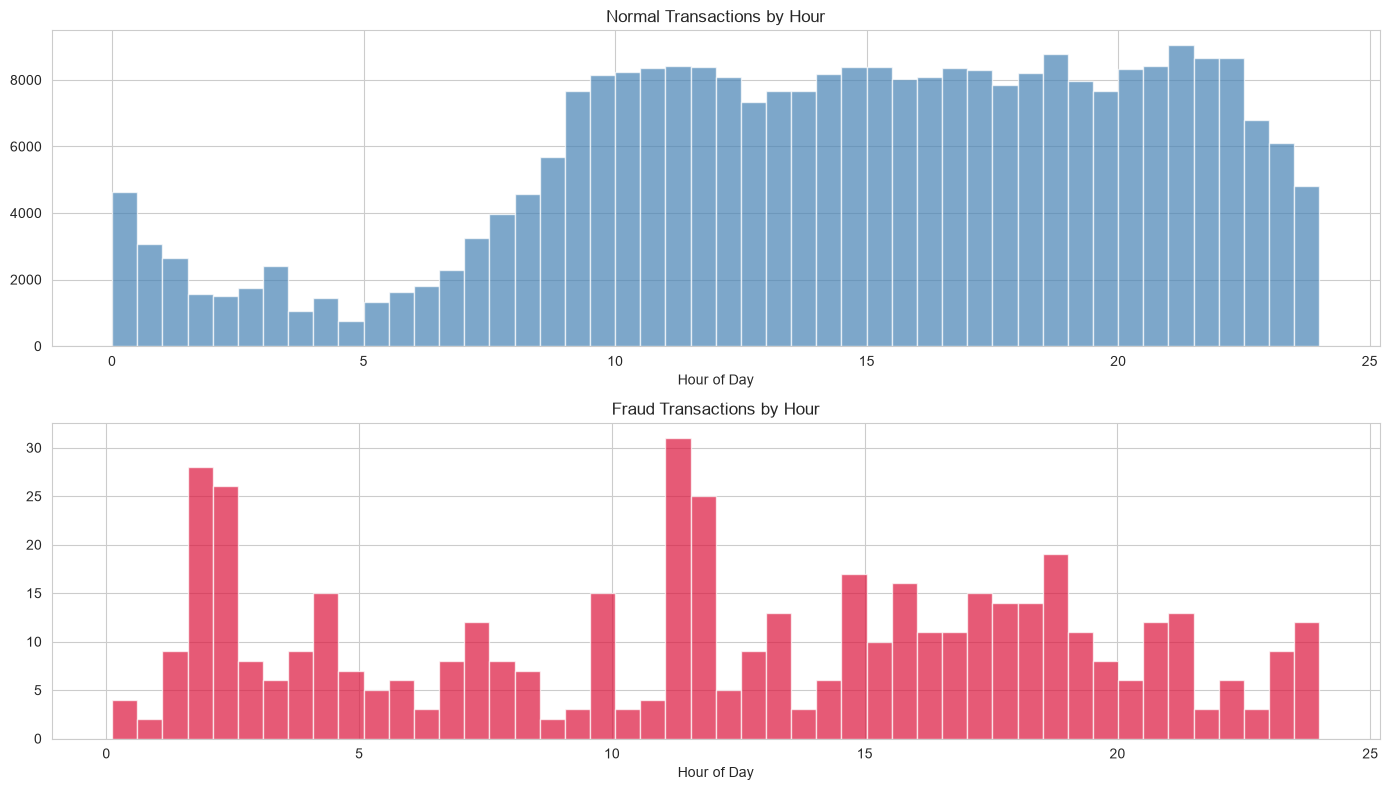

In [20]:
df["Hour"] = (df["Time"] / 3600) % 24

fig, ax = plt.subplots(2, 1, figsize=(14, 8))

ax[0].hist(df[df["Class"] == 0]["Hour"], bins=48, color="steelblue", alpha=0.7)
ax[0].set_title("Normal Transactions by Hour")
ax[0].set_xlabel("Hour of Day")

ax[1].hist(df[df["Class"] == 1]["Hour"], bins=48, color="crimson", alpha=0.7)
ax[1].set_title("Fraud Transactions by Hour")
ax[1].set_xlabel("Hour of Day")

plt.tight_layout()
plt.show()

# Correlation Heatmap

# Visualize how every feature correlates with every other. Shows
# multicollinearity and feature relationships at a glance. Helps us
# spot redundant features and understand the overall data structure.

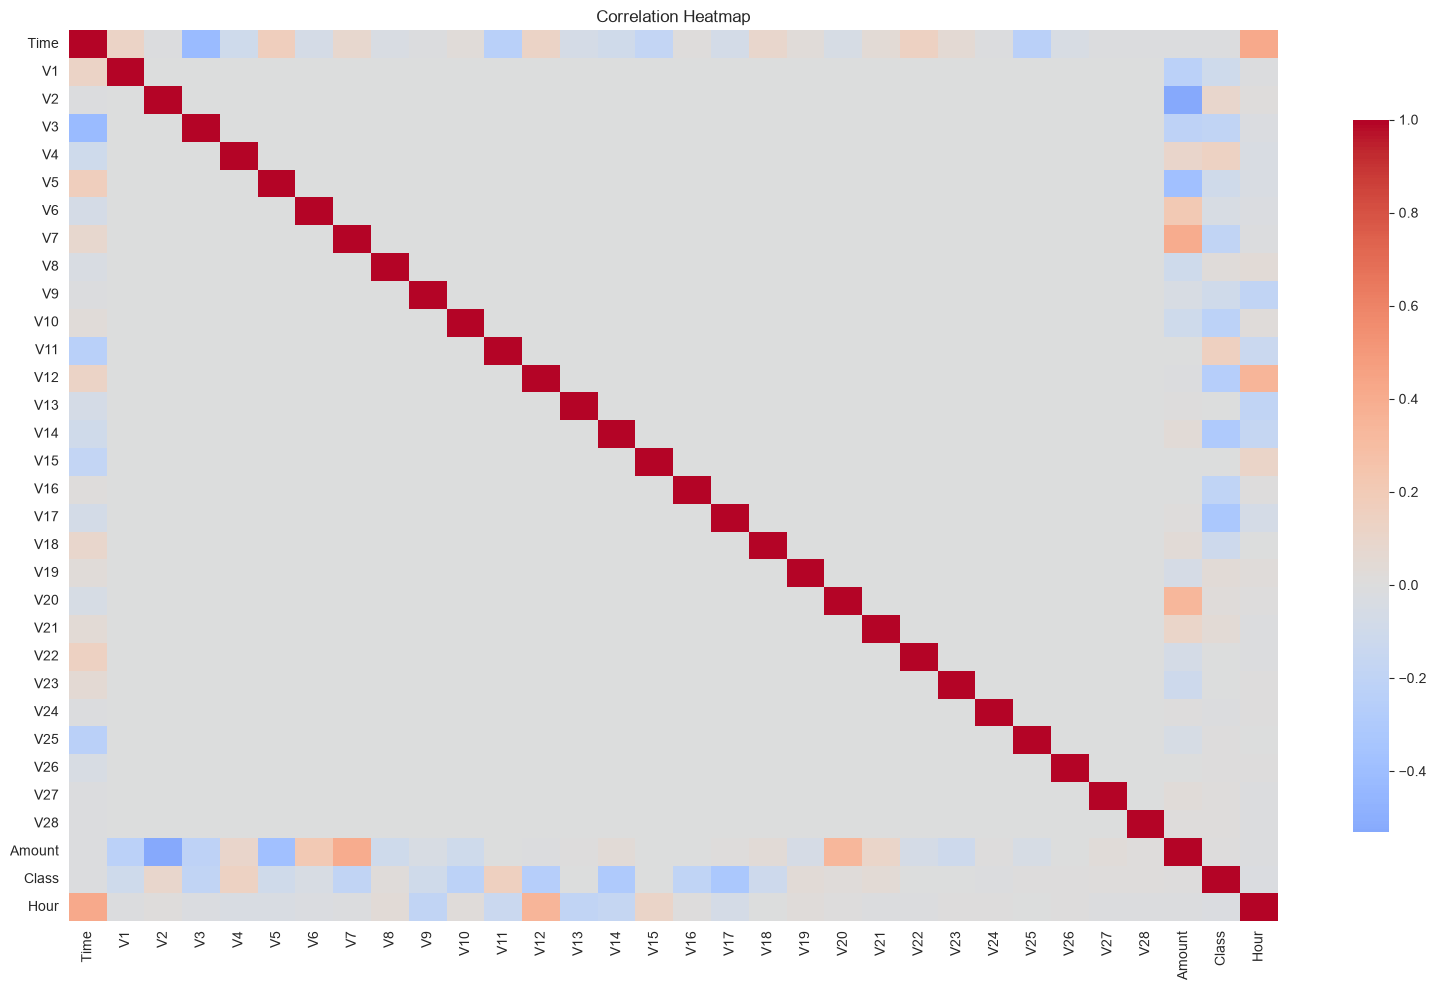

In [21]:
plt.figure(figsize=(16, 10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Feature–Fraud Correlation

# Sort every feature by correlation with Class (fraud). Top features
# (V17, V14, V12, V11, V4) drive fraud prediction. These will later
# be validated by SHAP — a good sanity check that our model learns
# the right signals.

In [22]:
fraud_corr = df.corr()["Class"].sort_values(ascending=False)
print("Top 10 positively correlated with fraud:\n", fraud_corr.head(11))
print("\nTop 10 negatively correlated with fraud:\n", fraud_corr.tail(10))

Top 10 positively correlated with fraud:
 Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64

Top 10 negatively correlated with fraud:
 V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


# Boxplots for Top Features

# Correlation only shows direction; boxplots show HOW SEPARATED
# distributions are between normal and fraud. Confirms these top
# features truly discriminate fraud — justifies feeding them raw
# into the model without extra transformations.

C:\Users\Rutu\AppData\Local\Temp\ipykernel_2404\2534165672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=feat, data=df, ax=ax,
C:\Users\Rutu\AppData\Local\Temp\ipykernel_2404\2534165672.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Normal", "Fraud"])
C:\Users\Rutu\AppData\Local\Temp\ipykernel_2404\2534165672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=feat, data=df, ax=ax,
C:\Users\Rutu\AppData\Local\Temp\ipykernel_2404\2534165672.py:9: UserWarning: set_ticklabels() should only be used with a fixed number 

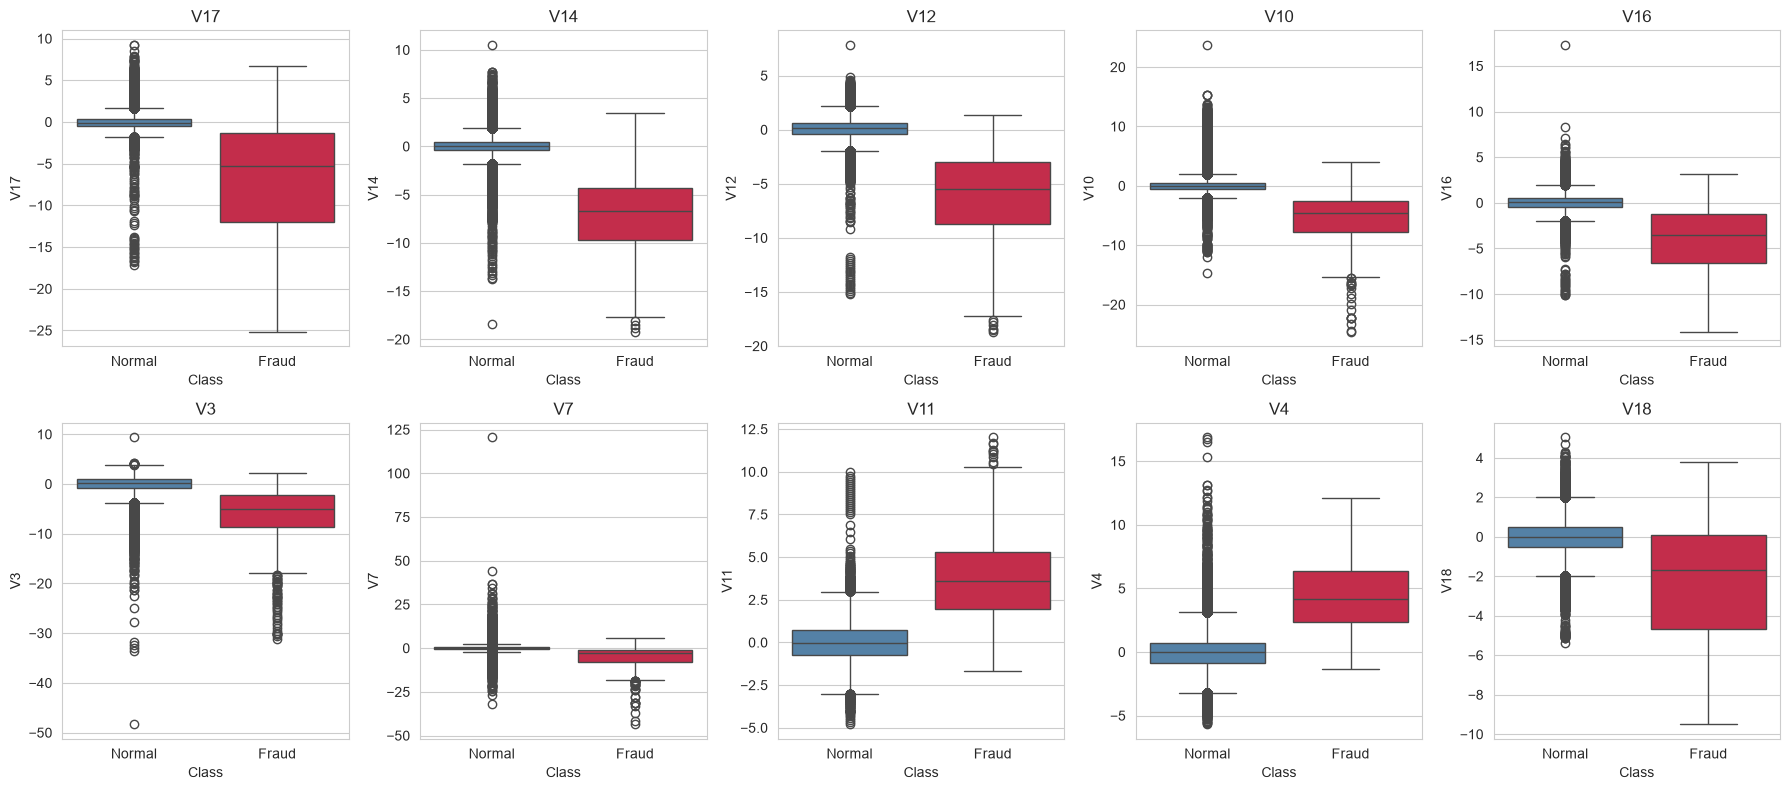

In [23]:
top_features = ["V17", "V14", "V12", "V10", "V16", "V3", "V7", "V11", "V4", "V18"]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, feat in enumerate(top_features):
    ax = axes[i // 5, i % 5]
    sns.boxplot(x="Class", y=feat, data=df, ax=ax,
                palette=["steelblue", "crimson"])
    ax.set_title(feat)
    ax.set_xticklabels(["Normal", "Fraud"])

plt.tight_layout()
plt.show()

# Save EDA Summary

# Save key EDA numbers (fraud %, duplicates, avg amounts) to JSON.
# README, dashboard, and the API's /stats endpoint will read this
# file — single source of truth, no magic numbers scattered around.

In [24]:
import os
import json

os.makedirs("../data/processed", exist_ok=True)

summary = {
    "total_rows": int(len(df)),
    "total_columns": int(df.shape[1]),
    "fraud_count": int(df["Class"].sum()),
    "fraud_pct": round(df["Class"].mean() * 100, 4),
    "duplicates": int(df.duplicated().sum()),
    "missing_values": int(df.isnull().sum().sum()),
    "avg_fraud_amount": round(df[df["Class"] == 1]["Amount"].mean(), 2),
    "avg_normal_amount": round(df[df["Class"] == 0]["Amount"].mean(), 2),
}
print(summary)

with open("../data/processed/eda_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved to data/processed/eda_summary.json")

{'total_rows': 284807, 'total_columns': 32, 'fraud_count': 492, 'fraud_pct': np.float64(0.1727), 'duplicates': 1081, 'missing_values': 0, 'avg_fraud_amount': np.float64(122.21), 'avg_normal_amount': np.float64(88.29)}

Saved to data/processed/eda_summary.json


# EDA Conclusions

1. **Severe Class Imbalance**: Only 0.172% transactions are fraud.
   → Use AUC-PR, Recall, F1 — NOT accuracy.

2. **Amount Matters**: Fraud amounts differ from normal.
   → Keep `Amount`, apply RobustScaler.

3. **Time Matters**: Fraud spikes at 2–4 AM.
   → Engineer `Hour` feature in feature engineering.

4. **Top Predictive Features**: V17, V14, V12 (negative), V11, V4 (positive).
   → These will dominate SHAP importance.

5. **Duplicates Present**: Drop them in preprocessing.

6. **No Missing Values**: Dataset is clean.

7. **Next Step**: Build `02_feature_engineering.ipynb` — scale Amount/Time,
   engineer Hour, split train/test with stratification, apply SMOTE.